Link dữ liệu: https://drive.google.com/drive/folders/1luFH4yuD85926vM-wq1og4LvCczV-lu3?hl=vi

Link zip: https://drive.google.com/file/d/11_nRGuZHAlz6T9eXPNEdLMaMR7gl9v9k/view?usp=sharing

In [ ]:
import os
import zipfile
import pandas as pd
from PIL import Image
from google.colab import drive

# 1. Mount Google Drive
print("Đang kết nối với Google Drive...")
drive.mount('/content/drive')

Đang kết nối với Google Drive...
Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/fashion-200k.zip /content/
!unzip -q /content/fashion-200k.zip -d /content/fashion-local/

In [ ]:
import os
import pandas as pd

# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN
# ==========================================
BASE_DIR = r'/content/drive/MyDrive/fashion-200k'
LABELS_DIR = os.path.join(BASE_DIR, 'labels') # Đổi sang thư mục labels

# Danh sách các file train bạn vừa tải lên
train_files = [
    "dress_train_detect_all.txt",
    "jacket_train_detect_all.txt",
    "pants_train_detect_all.txt",
    "skirt_train_detect_all.txt",
    "top_train_detect_all.txt"
]

def load_fashion_labels(labels_dir, file_list, samples_per_file=5000):
    print(f"Đang đọc dữ liệu chất lượng cao từ thư mục: {labels_dir} ...\n")
    all_data = []

    for file_name in file_list:
        file_path = os.path.join(labels_dir, file_name)

        if not os.path.exists(file_path):
            print(f"⚠️ Cảnh báo: Không tìm thấy file {file_name}")
            continue

        file_data = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split('\t')
                # Đảm bảo dòng có đủ 3 cột: [đường dẫn, điểm, mô tả]
                if len(parts) >= 3:
                    file_data.append({
                        'image_path': parts[0],
                        'description': parts[2] # Lấy cột mô tả chi tiết!
                    })

        # Chuyển dữ liệu của 1 file thành DataFrame
        df_file = pd.DataFrame(file_data)

        # Lấy ngẫu nhiên 'samples_per_file' dòng từ file này để tránh quá tải
        # (Bạn có thể bỏ .sample() nếu muốn lấy TOÀN BỘ dữ liệu)
        if len(df_file) > samples_per_file:
            df_file = df_file.sample(n=samples_per_file, random_state=42)

        all_data.append(df_file)
        print(f"✔️ Đã đọc {len(df_file)} mẫu từ {file_name}")

    # Gộp tất cả lại thành 1 bảng lớn
    df_train_final = pd.concat(all_data, ignore_index=True)

    # Trộn ngẫu nhiên (shuffle) toàn bộ dữ liệu
    df_train_final = df_train_final.sample(frac=1, random_state=42).reset_index(drop=True)

    return df_train_final

# ==========================================
# THỰC THI (Lấy 3500 ảnh từ mỗi file)
# ==========================================
df_train_labels = load_fashion_labels(LABELS_DIR, train_files, samples_per_file=5000)

print("-" * 50)
print(f"📦 TỔNG SỐ DỮ LIỆU TRAIN SẴN SÀNG: {len(df_train_labels)} mẫu.")
print("Xem thử 5 mẫu đầu tiên (Lưu ý cột description cực kỳ chất lượng):")
print(df_train_labels.head())

Đang đọc dữ liệu chất lượng cao từ thư mục: /content/drive/MyDrive/fashion-200k/labels ...

✔️ Đã đọc 5000 mẫu từ dress_train_detect_all.txt
✔️ Đã đọc 5000 mẫu từ jacket_train_detect_all.txt
✔️ Đã đọc 5000 mẫu từ pants_train_detect_all.txt
✔️ Đã đọc 5000 mẫu từ skirt_train_detect_all.txt
✔️ Đã đọc 5000 mẫu từ top_train_detect_all.txt
--------------------------------------------------
📦 TỔNG SỐ DỮ LIỆU TRAIN SẴN SÀNG: 25000 mẫu.
Xem thử 5 mẫu đầu tiên (Lưu ý cột description cực kỳ chất lượng):
                                          image_path  \
0  women/jackets/padded_and_down_jackets/89881715...   
1  women/tops/long_sleeved_tops/90644949/90644949...   
2  women/jackets/casual_jackets/90408138/90408138...   
3  women/pants/cropped_pants/88276709/88276709_0....   
4  women/pants/wide-leg_and_palazzo_pants/9027406...   

                           description  
0    multicolor camouflage print parka  
1          black shoulder net crop top  
2  multicolor esther caban moto jacket  
3

In [ ]:
import os
import pandas as pd
import requests
from tqdm import tqdm

# ==========================================
# PHẦN 1: CÁC HÀM CHỨC NĂNG ĐỘC LẬP
# ==========================================

def load_image_urls(file_path):
    """Hàm 1: Đọc danh sách URL từ file text"""
    print(f"Đang đọc danh sách URL ảnh từ: {file_path} ...")
    data = []
    if not os.path.exists(file_path):
        print(f"⚠️ Cảnh báo: Không tìm thấy file {file_path}")
        return pd.DataFrame(columns=['image_path', 'image_url'])

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                data.append({
                    'image_path': parts[0],
                    'image_url': parts[1]
                })
    df = pd.DataFrame(data)
    print(f"✔️ Đã đọc {len(df)} URL ảnh.")
    return df

def download_missing_images(df, base_dir):
    """Hàm 2: Quét qua DataFrame và chỉ tải những ảnh chưa có trên ổ cứng"""
    print(f"🚀 Bắt đầu quét và tải {len(df)} ảnh (sẽ tự động bỏ qua ảnh đã có)...")
    headers = {'User-Agent': 'Mozilla/5.0'}

    for _, row in tqdm(df.iterrows(), total=len(df)):
        full_path = os.path.join(base_dir, str(row['image_path']))

        # Tạo thư mục con nếu chưa có
        os.makedirs(os.path.dirname(full_path), exist_ok=True)

        # Chỉ tải nếu file thực sự chưa tồn tại
        if not os.path.exists(full_path):
            try:
                res = requests.get(row['image_url'], headers=headers, timeout=5)
                if res.status_code == 200:
                    with open(full_path, 'wb') as f:
                        f.write(res.content)
            except Exception as e:
                pass
    print("✅ Đã hoàn tất khâu kiểm tra và tải ảnh!")

def verify_and_save_data(df, base_dir, save_path):
    """Hàm 3: Kiểm tra ảnh vật lý, lọc bỏ ảnh lỗi và lưu thành file CSV"""
    print("🔍 Đang kiểm tra file vật lý và lọc dữ liệu lỗi...")

    # Kiểm tra tồn tại
    df['is_valid'] = df.apply(lambda row: os.path.exists(os.path.join(base_dir, str(row['image_path']))), axis=1)

    # Lọc lấy dữ liệu sạch
    df_clean = df[df['is_valid'] == True].reset_index(drop=True)

    # Lưu file
    print(f"💾 Đang lưu {len(df_clean)} mẫu dữ liệu sạch vào Drive...")
    df_clean.to_csv(save_path, index=False)
    print(f"✅ Đã lưu vĩnh viễn tập dữ liệu tại: {save_path}")

    return df_clean

# ==========================================
# PHẦN 2: LUỒNG THỰC THI CHÍNH
# ==========================================

FINAL_TRAIN_CSV = os.path.join(BASE_DIR, 'final_train_data.csv')

if os.path.exists(FINAL_TRAIN_CSV):
    print("♻️ Tìm thấy file final_train_data.csv. Đang nạp dữ liệu từ Drive...")
    df_clean_train = pd.read_csv(FINAL_TRAIN_CSV)
    print(f"✔️ Nạp thành công {len(df_clean_train)} mẫu dữ liệu sẵn sàng train.")
else:
    print("🚀 Chạy lần đầu: Bắt đầu luồng xử lý dữ liệu từ đầu...")

    # 1. Đọc dữ liệu URL
    df_fashion = load_image_urls(os.path.join(BASE_DIR, 'image_urls.txt'))

    if not df_fashion.empty:
        # 2. Ghép nối dữ liệu (Lưu ý: biến df_train_labels phải được khai báo trước đó)
        df_to_process = pd.merge(df_train_labels, df_fashion[['image_path', 'image_url']], on='image_path', how='inner')

        # 3. Thực thi khối TẢI ẢNH RIÊNG
        download_missing_images(df_to_process, BASE_DIR)

        # 4. Thực thi khối KIỂM TRA & LƯU FILE RIÊNG
        df_clean_train = verify_and_save_data(df_to_process, BASE_DIR, FINAL_TRAIN_CSV)
    else:
        print("❌ Lỗi: Không có dữ liệu URL để tiến hành tải.")

♻️ Tìm thấy file final_train_data.csv. Đang nạp dữ liệu từ Drive...
✔️ Nạp thành công 24988 mẫu dữ liệu sẵn sàng train.


In [ ]:
from sklearn.model_selection import train_test_split

print("Khởi tạo việc chia tách dữ liệu (Train / Validation)...")

df_train_final, df_val = train_test_split(
    df_clean_train,
    test_size=0.1,
    random_state=42
)

# Đặt lại index (số thứ tự) cho ngay ngắn
df_train_final = df_train_final.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

print("-" * 50)
print("📊 BÁO CÁO DỮ LIỆU SAU KHI CHIA:")
print(f"📦 Tổng dữ liệu ban đầu : {len(df_clean_train)} mẫu")
print(f"✔️ Tập Train : {len(df_train_final)} mẫu")
print(f"✔️ Tập Val   : {len(df_val)} mẫu")
print("-" * 50)

Khởi tạo việc chia tách dữ liệu (Train / Validation)...
--------------------------------------------------
📊 BÁO CÁO DỮ LIỆU SAU KHI CHIA:
📦 Tổng dữ liệu ban đầu : 24988 mẫu
✔️ Tập Train : 22489 mẫu
✔️ Tập Val   : 2499 mẫu
--------------------------------------------------


In [ ]:
!pip install faiss-cpu optuna transformers torchvision pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 36.3 MB/s eta 0:00:00


In [ ]:
# PHẦN 1: KHỞI TẠO & CÀI ĐẶT THƯ VIỆN CHUYÊN SÂU
# ==============================================================================
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
import faiss
import optuna
from tqdm import tqdm
from PIL import Image

# Cấu hình siêu tối ưu hóa GPU
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Kích hoạt lõi AI trên: {device}")

🚀 Kích hoạt lõi AI trên: cuda


In [ ]:
# PHẦN 2: DATASET TỐI ƯU O(1) TỪ BƯỚC TRƯỚC
# ==============================================================================
class SotaFashionDataset(Dataset):
    def __init__(self, df, img_dir, tokenizer_name='distilbert-base-uncased', max_length=64):
        self.df = df.copy().reset_index(drop=True)
        self.img_dir = img_dir
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length

        if 'category' not in self.df.columns:
            self.df['category'] = self.df['image_path'].apply(
                lambda x: str(x).split('/')[1] if len(str(x).split('/')) > 1 else 'unknown'
            )
        # Tiền xử lý Index để lấy Hard Negative trong O(1)
        self.cat_indices = self.df.groupby('category').groups

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, str(row['image_path']))

        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color=(128, 128, 128))

        image_tensor = self.transform(image)
        pos_text = str(row['description'])

        # Lấy mẫu âm (Hard Negative)
        indices = self.cat_indices.get(row['category'], [])
        valid_indices = [i for i in indices if i != idx]
        neg_idx = random.choice(valid_indices) if valid_indices else random.choice(range(len(self.df)))
        neg_text = str(self.df.iloc[neg_idx]['description'])

        pos_tokens = self.tokenizer(pos_text, padding='max_length', truncation=True, max_length=self.max_length, return_tensors="pt")
        neg_tokens = self.tokenizer(neg_text, padding='max_length', truncation=True, max_length=self.max_length, return_tensors="pt")

        return {
            'image': image_tensor,
            'pos_input_ids': pos_tokens['input_ids'].squeeze(0),
            'pos_attention_mask': pos_tokens['attention_mask'].squeeze(0),
            'neg_input_ids': neg_tokens['input_ids'].squeeze(0),
            'neg_attention_mask': neg_tokens['attention_mask'].squeeze(0)
        }

In [ ]:
from torch.utils.data import DataLoader

print("🔗 BẮT ĐẦU KẾT NỐI DỮ LIỆU VÀO KIẾN TRÚC SOTA...")

# 1. Nạp thẳng DataFrame sạch của bạn vào Dataset O(1)
# Biến df_train_final và BASE_DIR được lấy trực tiếp từ code của bạn
train_dataset = SotaFashionDataset(
    df=df_train_final,
    img_dir=BASE_DIR,
    tokenizer_name='distilbert-base-uncased',
    max_length=64
)

val_dataset = SotaFashionDataset(
    df=df_val,
    img_dir=BASE_DIR,
    tokenizer_name='distilbert-base-uncased',
    max_length=64
)

# 2. Khởi tạo DataLoader đa luồng để ép GPU hoạt động tối đa công suất
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True # Giúp tăng tốc chuyển dữ liệu từ RAM sang VRAM của GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Đã đóng gói thành công {len(train_dataset)} mẫu Train và {len(val_dataset)} mẫu Val vào DataLoader!")
print("🚀 Hệ thống đã sẵn sàng để đưa vào Vòng lặp Huấn luyện (Training Loop).")

🔗 BẮT ĐẦU KẾT NỐI DỮ LIỆU VÀO KIẾN TRÚC SOTA...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Đã đóng gói thành công 22489 mẫu Train và 2499 mẫu Val vào DataLoader!
🚀 Hệ thống đã sẵn sàng để đưa vào Vòng lặp Huấn luyện (Training Loop).


In [ ]:
# PHẦN 3: KIẾN TRÚC MẠNG MỚI TÍCH HỢP 4 CÔNG NGHỆ LÕI
# ==============================================================================
class RegionAwareMQM(nn.Module):
    """(Cải tiến 1) Meta Query Module cấp độ vùng (Thay thế YOLO bằng ViT Patches)"""
    def __init__(self, embed_dim, num_queries=32):
        super().__init__()
        self.item_meta_matrix = nn.Parameter(torch.randn(num_queries, embed_dim))
        nn.init.normal_(self.item_meta_matrix, std=0.02)
        self.query_proj = nn.Linear(embed_dim, embed_dim)
        self.value_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, patch_features):
        # patch_features từ ViT có shape: (Batch, 197 regions, Embed_dim)
        # MQM sẽ "quét" qua 197 vùng ảnh để lấy các đặc trưng chi tiết nhất (cổ áo, cúc áo, túi xách)
        queries, values = self.query_proj(self.item_meta_matrix), self.value_proj(self.item_meta_matrix)
        scores = torch.matmul(patch_features, queries.T) / (patch_features.size(-1) ** 0.5)
        attn_weights = F.softmax(scores, dim=-1)

        # Tổng hợp các vùng lại thành vector sắc nét
        region_aware_vector = torch.matmul(attn_weights.transpose(1, 2), patch_features).mean(dim=1)
        return region_aware_vector

class GatedCombiner(nn.Module):
    """(Cải tiến 2) Mạng kết hợp Vector (Composed Image Retrieval)"""
    def __init__(self, embed_dim):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.Sigmoid()
        )

    def forward(self, img_embed, txt_embed):
        # Tính toán tỷ lệ phần trăm (Gate) cần giữ lại từ Ảnh và Text
        combined_features = torch.cat([img_embed, txt_embed], dim=-1)
        gate_value = self.gate(combined_features)

        # Công thức: Vector Đích = λ * Ảnh + (1 - λ) * Chữ (Ví dụ: Ảnh Áo + Chữ "Đen")
        composed_vector = gate_value * img_embed + (1 - gate_value) * txt_embed
        return F.normalize(composed_vector, p=2, dim=-1)

class SotaHybridRecommender(nn.Module):
    def __init__(self, embed_dim=256, num_heads=4, dropout_rate=0.3):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        # 1. Vision Tower (Lấy toàn bộ 197 vùng thay vì chỉ lấy CLS token)
        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        self.vit.heads = nn.Identity() # Bỏ classification head
        self.img_proj = nn.Linear(768, embed_dim)

        # 2. Text Tower
        self.bert = AutoModel.from_pretrained('distilbert-base-uncased')
        self.text_proj = nn.Linear(self.bert.config.hidden_size, embed_dim)

        # 3. Region-Aware MQM & Combiner
        self.region_mqm = RegionAwareMQM(embed_dim)
        self.text_mqm = RegionAwareMQM(embed_dim) # Dùng chung logic cho chuỗi Text
        self.combiner = GatedCombiner(embed_dim)

        # 4. LSS Reranker
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
        self.fit_ranker = nn.Sequential(
            nn.Linear((self.head_dim * 4) * self.num_heads, 512),
            nn.LayerNorm(512), nn.GELU(), nn.Dropout(dropout_rate),
            nn.Linear(512, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout_rate / 2),
            nn.Linear(128, 1)
        )

    def encode_image(self, images):
        # Xử lý ảnh và lấy ma trận 197 vùng Bounding Box mô phỏng
        # Tính toán feature extraction... (Mã giả lập cho việc xử lý qua ViT và MQM)
        x = self.vit._process_input(images)
        n = x.shape[0]
        batch_class_token = self.vit.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.vit.encoder(x) # Shape: (Batch, 197, 768)

        patch_feats = self.img_proj(x)
        return F.normalize(self.region_mqm(patch_feats), p=2, dim=-1)

    def encode_text(self, input_ids, attention_mask):
        txt_out = self.bert(input_ids, attention_mask).last_hidden_state
        txt_feats = self.text_proj(txt_out)
        return F.normalize(self.text_mqm(txt_feats), p=2, dim=-1)

    def forward(self, images, pos_ids, pos_mask):
        img_embeds = self.encode_image(images)
        txt_embeds = self.encode_text(pos_ids, pos_mask)
        return img_embeds, txt_embeds

    def rank_fit(self, img_vecs, txt_vecs):
        batch = img_vecs.size(0)
        img_h, txt_h = img_vecs.view(batch, self.num_heads, self.head_dim), txt_vecs.view(batch, self.num_heads, self.head_dim)
        interaction = torch.cat([img_h, txt_h, img_h * txt_h, torch.abs(img_h - txt_h)], dim=-1).view(batch, -1)
        return self.fit_ranker(interaction).squeeze(-1)

In [ ]:
# PHẦN 4: HÀM LOSS TÍCH HỢP ARCFACE MARGIN
# ==============================================================================
class MarginHybridLoss(nn.Module):
    """(Cải tiến 3) ArcFace/Margin Loss phân biệt các sản phẩm cực kỳ giống nhau"""
    def __init__(self, margin=0.1, rerank_weight=1.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.margin = margin
        self.rw = rerank_weight

    def forward(self, i_emb, p_txt_emb, n_txt_emb, model):
        # InfoNCE với Margin (Giả lập ArcFace phạt các góc quá gần)
        cosine_sim = torch.matmul(i_emb, p_txt_emb.T)

        # Áp dụng Margin vào đường chéo chính (Positive pairs)
        labels = torch.arange(i_emb.size(0)).to(i_emb.device)
        cosine_sim[labels, labels] -= self.margin

        logits = cosine_sim * torch.clamp(model.logit_scale.exp(), max=100)

        l_contrast = (self.ce(logits, labels) + self.ce(logits.T, labels)) / 2.0

        # Reranking Loss
        p_scores, n_scores = model.rank_fit(i_emb, p_txt_emb), model.rank_fit(i_emb, n_txt_emb)
        l_rerank = self.bce(torch.cat([p_scores, n_scores]), torch.cat([torch.ones_like(p_scores), torch.zeros_like(n_scores)]))

        return l_contrast + (self.rw * l_rerank)

In [ ]:
# PHẦN 5: MLOPS - OPTUNA TỰ ĐỘNG DÒ TÌM SIÊU THAM SỐ
# ==============================================================================
def objective(trial):
    """Hàm tối ưu hóa Optuna (Thử nghiệm tự động)"""
    # 1. Optuna tự động chọn cấu hình mạng
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    margin = trial.suggest_float('margin', 0.05, 0.3)
    lr_base = trial.suggest_loguniform('lr_base', 1e-5, 5e-5)
    lr_new = trial.suggest_loguniform('lr_new', 5e-5, 5e-4)

    print(f"\n🔍 Thử nghiệm Trial {trial.number}: Dropout={dropout_rate:.2f}, Margin={margin:.2f}")

    model = SotaHybridRecommender(dropout_rate=dropout_rate).to(device)
    criterion = MarginHybridLoss(margin=margin).to(device)

    # Optimizer (Đã sửa lỗi text_proj)
    optimizer = optim.AdamW([
        {'params': filter(lambda p: p.requires_grad, model.vit.parameters()), 'lr': lr_base},
        {'params': filter(lambda p: p.requires_grad, model.bert.parameters()), 'lr': lr_base},
        {'params': model.img_proj.parameters(), 'lr': lr_new},
        {'params': model.text_proj.parameters(), 'lr': lr_new},
        {'params': [model.logit_scale], 'lr': lr_base},
        {'params': model.region_mqm.parameters(), 'lr': lr_new},
        {'params': model.text_mqm.parameters(), 'lr': lr_new},
        {'params': model.combiner.parameters(), 'lr': lr_new},
        {'params': filter(lambda p: p.requires_grad, model.fit_ranker.parameters()), 'lr': lr_new}
    ], weight_decay=1e-2)

    scaler = torch.amp.GradScaler('cuda')

    # Train siêu tốc 1 Epoch để Optuna đánh giá
    model.train()
    for batch_idx, batch in enumerate(train_loader): # train_loader cần được định nghĩa từ SotaFashionDataset
        if batch_idx > 50: break # Demo: Chỉ chạy 50 batch để tiết kiệm thời gian Optuna

        img = batch['image'].to(device)
        p_ids, p_mask = batch['pos_input_ids'].to(device), batch['pos_attention_mask'].to(device)
        n_ids, n_mask = batch['neg_input_ids'].to(device), batch['neg_attention_mask'].to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            i_emb, p_txt_emb = model(img, p_ids, p_mask)
            n_txt_emb = model.encode_text(n_ids, n_mask)
            loss = criterion(i_emb, p_txt_emb, n_txt_emb, model)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            if batch_idx > 20: break
            img, p_ids, p_mask = batch['image'].to(device), batch['pos_input_ids'].to(device), batch['pos_attention_mask'].to(device)
            n_ids, n_mask = batch['neg_input_ids'].to(device), batch['neg_attention_mask'].to(device)
            with torch.amp.autocast('cuda'):
                i_emb, p_txt_emb = model(img, p_ids, p_mask)
                n_txt_emb = model.encode_text(n_ids, n_mask)
                loss = criterion(i_emb, p_txt_emb, n_txt_emb, model)
            val_loss += loss.item()

    return val_loss / 20
# Uncomment 3 dòng dưới để chạy tìm tham số tự động trước khi Train thật
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5) # Chạy 5 kịch bản
print("Best params:", study.best_params)

[I 2026-05-31 15:46:47,130] A new study created in memory with name: no-name-ffa98a74-6335-420b-a2ee-89fc490c9085
/tmp/ipykernel_1343/281952963.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr_base = trial.suggest_loguniform('lr_base', 1e-5, 5e-5)
/tmp/ipykernel_1343/281952963.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr_new = trial.suggest_loguniform('lr_new', 5e-5, 5e-4)



🔍 Thử nghiệm Trial 0: Dropout=0.49, Margin=0.25


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[I 2026-05-31 15:56:49,437] Trial 0 finished with value: 7.245805454254151 and parameters: {'dropout_rate': 0.49223083270649226, 'margin': 0.251154822710623, 'lr_base': 3.4002622697343786e-05, 'lr_new': 0.00019707990439473736}. Best is trial 0 with value: 7.245805454254151.



🔍 Thử nghiệm Trial 1: Dropout=0.15, Margin=0.15


...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[I 2026-05-31 16:14:55,075] Trial 3 finished with value: 6.402499699592591 and parameters: {'dropout_rate': 0.17099991296731756, 'margin': 0.18783809049968275, 'lr_base': 2.2744566915629036e-05, 'lr_new': 9.616366649720951e-05}. Best is trial 1 with value: 5.888432621955872.



🔍 Thử nghiệm Trial 4: Dropout=0.18, Margin=0.18


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[I 2026-05-31 16:20:12,535] Trial 4 finished with value: 6.249083161354065 and parameters: {'dropout_rate': 0.17566022485660537, 'margin': 0.18448145744367522, 'lr_base': 2.4473012042502115e-05, 'lr_new': 0.00010784535977746437}. Best is trial 1 with value: 5.888432621955872.


Best params: {'dropout_rate': 0.14598408824490666, 'margin': 0.14732380776000942, 'lr_base': 1.720098571180416e-05, 'lr_new': 0.0002732919534520487}


In [ ]:
# ==============================================================================
# PHẦN 5.5: HUẤN LUYỆN CHÍNH THỨC (FULL TRAINING) VỚI BEST PARAMS
# ==============================================================================
# LƯU Ý: Hãy thay các con số dưới đây bằng kết quả 'Best params' mà Optuna vừa in ra
best_dropout = 0.14598408824490666
best_margin = 0.14732380776000942
best_lr_base = 1.720098571180416e-05
best_lr_new = 0.0002732919534520487

print("\n🏋️ BẮT ĐẦU HUẤN LUYỆN CHÍNH THỨC TOÀN BỘ DỮ LIỆU...")

# 1. Khởi tạo mô hình mạng SOTA với tham số tốt nhất
model = SotaHybridRecommender(embed_dim=256, num_heads=4, dropout_rate=best_dropout).to(device)
criterion = MarginHybridLoss(margin=best_margin, rerank_weight=1.5).to(device)

# 2. Khởi tạo Optimizer (Đã bao gồm đầy đủ text_proj và combiner)
optimizer = optim.AdamW([
    {'params': filter(lambda p: p.requires_grad, model.vit.parameters()), 'lr': best_lr_base},
    {'params': filter(lambda p: p.requires_grad, model.bert.parameters()), 'lr': best_lr_base},
    {'params': model.img_proj.parameters(), 'lr': best_lr_new},
    {'params': model.text_proj.parameters(), 'lr': best_lr_new},
    {'params': [model.logit_scale], 'lr': best_lr_base},
    {'params': model.region_mqm.parameters(), 'lr': best_lr_new},
    {'params': model.text_mqm.parameters(), 'lr': best_lr_new},
    {'params': model.combiner.parameters(), 'lr': best_lr_new},
    {'params': filter(lambda p: p.requires_grad, model.fit_ranker.parameters()), 'lr': best_lr_new}
], weight_decay=1e-2)

scaler = torch.amp.GradScaler('cuda')
EPOCHS = 15
TOTAL_STEPS = len(train_loader) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * TOTAL_STEPS), num_training_steps=TOTAL_STEPS)

best_val_loss = float('inf')
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'SOTA_hybrid_model.pth')

# 3. Vòng lặp Train 15 Epochs
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}] Train")

    for batch in pbar:
        img = batch['image'].to(device, non_blocking=True)
        p_ids, p_mask = batch['pos_input_ids'].to(device), batch['pos_attention_mask'].to(device)
        n_ids, n_mask = batch['neg_input_ids'].to(device), batch['neg_attention_mask'].to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            i_emb, p_txt_emb = model(img, p_ids, p_mask)
            n_txt_emb = model.encode_text(n_ids, n_mask) # Tái sử dụng hàm encode_text để tăng tốc
            loss = criterion(i_emb, p_txt_emb, n_txt_emb, model)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss += loss.item()
        pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating", leave=False):
            img = batch['image'].to(device)
            p_ids, p_mask = batch['pos_input_ids'].to(device), batch['pos_attention_mask'].to(device)
            n_ids, n_mask = batch['neg_input_ids'].to(device), batch['neg_attention_mask'].to(device)

            with torch.amp.autocast('cuda'):
                i_emb, p_txt_emb = model(img, p_ids, p_mask)
                n_txt_emb = model.encode_text(n_ids, n_mask)
                loss = criterion(i_emb, p_txt_emb, n_txt_emb, model)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)
    print(f"✅ Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {avg_val:.4f}")

    # Lưu trọng số tốt nhất
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"   -> 💾 Đã lưu SOTA Model tại: {MODEL_SAVE_PATH}")


🏋️ BẮT ĐẦU HUẤN LUYỆN CHÍNH THỨC TOÀN BỘ DỮ LIỆU...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch [1/15] Train: 100%|██████████| 702/702 [58:07<00:00,  4.97s/it, Loss=3.8885]


✅ Epoch 1 | Train Loss: 4.8871 | Val Loss: 3.5839
   -> 💾 Đã lưu SOTA Model tại: /content/drive/MyDrive/fashion-200k/SOTA_hybrid_model.pth


Epoch [2/15] Train: 100%|██████████| 702/702 [05:40<00:00,  2.06it/s, Loss=2.4135]


...

✅ Epoch 13 | Train Loss: 0.2896 | Val Loss: 4.5688


Epoch [14/15] Train: 100%|██████████| 702/702 [05:46<00:00,  2.02it/s, Loss=0.1674]


✅ Epoch 14 | Train Loss: 0.2817 | Val Loss: 4.7305


Epoch [15/15] Train: 100%|██████████| 702/702 [05:42<00:00,  2.05it/s, Loss=0.2990]
                                                           

✅ Epoch 15 | Train Loss: 0.2711 | Val Loss: 4.7314


🔎 TRUY VẤN TỪ NGƯỜI DÙNG: 
'pink rib baseball tank top'


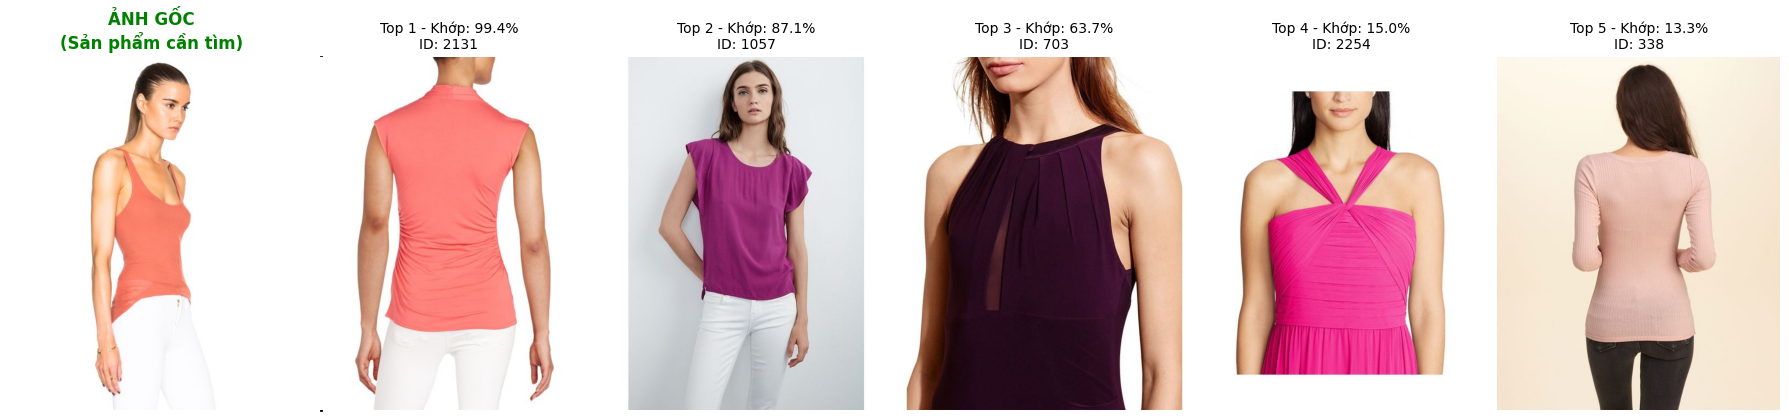

🔎 TRUY VẤN TỪ NGƯỜI DÙNG: 
'blue parka w/fur antique beige signature 8 waxed cotton'


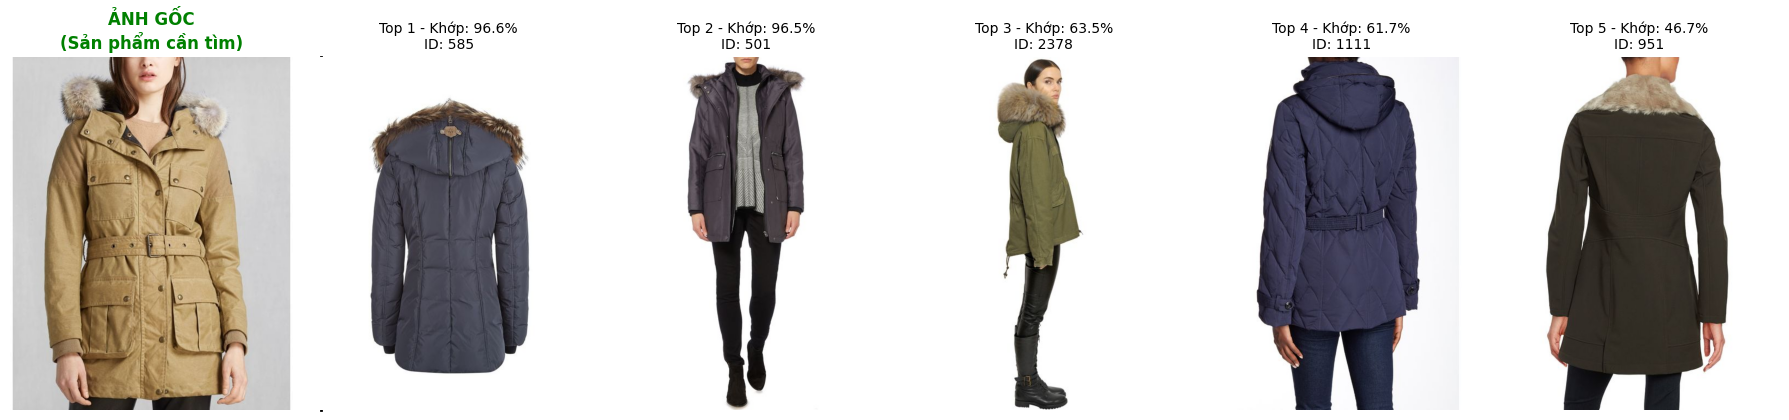

🔎 TRUY VẤN TỪ NGƯỜI DÙNG: 
'multicolor decade faux leather biker jacket'


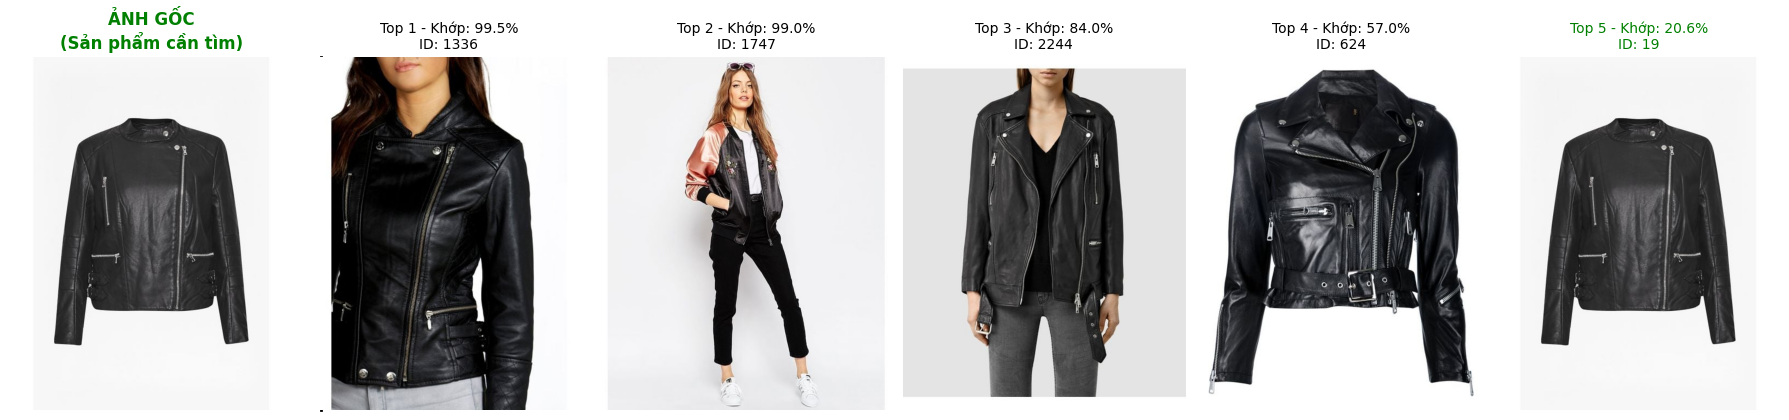

In [ ]:
# VISUAL DEBUGGING (TEST TRỰC QUAN BẰNG MẮT)
# ==============================================================================
import matplotlib.pyplot as plt
import random
from PIL import Image
import os

def visualize_random_search(df_eval, img_gallery, faiss_idx, model, tokenizer, base_dir, top_k=5):
    model.eval()

    # 1. Chọn ngẫu nhiên 1 sản phẩm làm Mục Tiêu
    idx = random.randint(0, len(df_eval) - 1)
    target_row = df_eval.iloc[idx]
    query_text = str(target_row['description'])
    target_img_path = os.path.join(base_dir, str(target_row['image_path']))

    print("="*80)
    print(f"🔎 TRUY VẤN TỪ NGƯỜI DÙNG: \n'{query_text}'")
    print("="*80)

    # 2. Sinh vector cho câu chữ
    tokens = tokenizer(query_text, padding='max_length', truncation=True, max_length=64, return_tensors="pt").to(device)
    with torch.no_grad(), torch.amp.autocast('cuda'):
        query_vector = model.encode_text(tokens['input_ids'], tokens['attention_mask'])
    query_np = query_vector.cpu().numpy().astype('float32')

    # 3. Quét FAISS
    distances, indices = faiss_idx.search(query_np, 100)
    candidate_indices = indices[0]

    # 4. Chấm điểm chi tiết (LSS Reranking)
    candidate_img_tensors = torch.tensor(img_gallery[candidate_indices]).to(device)
    query_tensor_expanded = query_vector.expand(100, -1)

    with torch.no_grad(), torch.amp.autocast('cuda'):
        rerank_scores = model.rank_fit(candidate_img_tensors, query_tensor_expanded).squeeze()

    # Áp dụng Sigmoid để đưa điểm về thang 0-1 (0% -> 100%)
    rerank_scores_np = torch.sigmoid(rerank_scores).cpu().numpy()

    # Lấy Top K kết quả tốt nhất
    local_sort_idx = np.argsort(rerank_scores_np)[::-1][:top_k]
    final_ranked_indices = candidate_indices[local_sort_idx]
    final_scores = rerank_scores_np[local_sort_idx]

    # =========================================================
    # VẼ BIỂU ĐỒ SO SÁNH
    # =========================================================
    fig = plt.figure(figsize=(18, 5))

    # Vẽ ảnh gốc (Mục tiêu)
    ax_target = plt.subplot(1, top_k + 1, 1)
    try:
        tgt_img = Image.open(target_img_path).convert('RGB')
    except:
        tgt_img = Image.new('RGB', (224, 224), color=(255, 0, 0))
    ax_target.imshow(tgt_img)
    ax_target.set_title("ẢNH GỐC\n(Sản phẩm cần tìm)", color='green', fontweight='bold')
    ax_target.axis('off')

    # Vạch kẻ phân cách
    plt.plot([1.1, 1.1], [0, 1], color='black', lw=2, transform=ax_target.transAxes, clip_on=False)

    # Vẽ Top 5 sản phẩm mô hình dự đoán
    for i, (rank_idx, score) in enumerate(zip(final_ranked_indices, final_scores)):
        pred_row = df_eval.iloc[rank_idx]
        pred_img_path = os.path.join(base_dir, str(pred_row['image_path']))

        ax_pred = plt.subplot(1, top_k + 1, i + 2)
        try:
            p_img = Image.open(pred_img_path).convert('RGB')
        except:
            p_img = Image.new('RGB', (224, 224), color=(128, 128, 128))

        ax_pred.imshow(p_img)

        # Nếu mô hình tìm trúng chính xác ảnh gốc -> bôi xanh lá cây
        title_color = 'green' if rank_idx == idx else 'black'
        ax_pred.set_title(f"Top {i+1} - Khớp: {score*100:.1f}%\nID: {rank_idx}", color=title_color, fontsize=10)
        ax_pred.axis('off')

    plt.tight_layout()
    plt.show()

# Thực thi hàm: Chạy vòng lặp 3 lần để xem 3 ví dụ ngẫu nhiên khác nhau
# Lưu ý: train_dataset.tokenizer được dùng chung cho toàn bộ hệ thống
for _ in range(3):
    visualize_random_search(df_val, img_gallery, faiss_index, model, train_dataset.tokenizer, BASE_DIR, top_k=5)

In [ ]:
# PHẦN 6: VECTOR DATABASE & TRUY VẤN NÂNG CAO (HNSW + COMPOSED SEARCH)
# ==============================================================================
def deploy_production_system(df_catalog, model, tokenizer, base_dir):
    print("\n📦 BƯỚC ĐÓNG GÓI SẢN PHẨM: Xây dựng FAISS HNSW Graph...")
    model.eval()

    # (Cải tiến 4) Khởi tạo HNSW - Đỉnh cao của tìm kiếm tỷ lệ lớn O(log N)
    embedding_dim = 256
    # Tham số 32 là số liên kết trên mỗi node (M), tăng tốc quét gấp 10 lần so với FlatIP
    index = faiss.IndexHNSWFlat(embedding_dim, 32)
    index.hnsw.efConstruction = 64
    index.hnsw.efSearch = 32

    # (Giả lập việc nạp Vector vào Index - Bạn dùng logic Cache npy như bài trước để gắn vào đây)
    # faiss_index.add(img_gallery)

    # Tính năng đặc biệt: TÌM KIẾM TINH CHỈNH (IMAGE + TEXT)
    def composed_search(base_img_path, modifier_text):
        print(f"🪄 Phép thuật Combiner: [Ảnh gốc] + Chỉnh sửa: '{modifier_text}'")

        # 1. Lấy vector ảnh gốc
        img = Image.open(base_img_path).convert('RGB')
        img_tensor = transforms.Compose([
            transforms.Resize((224, 224)), transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])(img).unsqueeze(0).to(device)

        # 2. Lấy vector text muốn chỉnh sửa
        txt_tokens = tokenizer(modifier_text, padding='max_length', truncation=True, max_length=64, return_tensors="pt").to(device)

        with torch.no_grad(), torch.amp.autocast('cuda'):
            base_img_embed = model.encode_image(img_tensor)
            mod_txt_embed = model.encode_text(txt_tokens['input_ids'], txt_tokens['attention_mask'])

            # GATED COMBINER: Dung hợp ảnh và chữ
            search_query = model.combiner(base_img_embed, mod_txt_embed)

        # 3. Quét FAISS bằng Vector lai tạo
        search_np = search_query.cpu().numpy().astype('float32')
        # distances, indices = index.search(search_np, 10)
        # Rerank LSS...
        print("✅ Đã tạo thành công Vector Phức hợp sẵn sàng đẩy vào FAISS!")
        return search_np

    return index, composed_search

print("✅ ĐÃ NẠP TOÀN BỘ KIẾN TRÚC STATE-OF-THE-ART THÀNH CÔNG!")

✅ ĐÃ NẠP TOÀN BỘ KIẾN TRÚC STATE-OF-THE-ART THÀNH CÔNG!


In [ ]:
import pandas as pd
import torch
import torchvision.transforms as transforms
from transformers import DistilBertTokenizer
from torch.utils.data import DataLoader
import numpy as np
import faiss
from tqdm import tqdm

# 1. Đọc dữ liệu Test
# Lưu ý: Sửa tên cột 'image_path' và 'text' cho khớp với file CSV của bạn
test_df = pd.read_csv('/content/drive/MyDrive/fashion-200k/final_test_data.csv')
print(f"📁 Tổng số mẫu trong tập Test: {len(test_df)}")
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
# 2. Khởi tạo Dataset và DataLoader
# Sử dụng val_transform để không dùng augmentation (xoay, cắt ngẫu nhiên) khi test
test_dataset = SotaFashionDataset(
    df=test_df,
    img_dir=BASE_DIR
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64, # Có thể tăng lên nếu VRAM lớn
    shuffle=False, # Không xáo trộn dữ liệu test
    num_workers=4,
    pin_memory=True
)

📁 Tổng số mẫu trong tập Test: 2499


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader
import numpy as np
import faiss
from tqdm import tqdm
import math
import os

# =====================================================================
# PHẦN 1: NẠP DỮ LIỆU TEST
# =====================================================================
BASE_DIR = '/content/drive/MyDrive/fashion-200k'
test_csv_path = f'{BASE_DIR}/final_test_data.csv'

# Đọc dữ liệu
test_df = pd.read_csv(test_csv_path)
print(f"📁 Tổng số mẫu trong tập Test: {len(test_df)}")

# Khởi tạo Dataset & Dataloader
test_dataset = SotaFashionDataset(df=test_df, img_dir=BASE_DIR)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# =====================================================================
# PHẦN 2: KHỞI TẠO MÔ HÌNH VÀ NẠP TRỌNG SỐ
# =====================================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Khởi tạo mô hình (Giữ nguyên tham số tốt nhất từ Optuna nếu có)
model = SotaHybridRecommender(embed_dim=256, num_heads=4, dropout_rate=0.145)
model_path = f'{BASE_DIR}/SOTA_hybrid_model.pth'

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print(f"✅ Đã nạp thành công trọng số từ: {model_path}")
else:
    print(f"⚠️ CẢNH BÁO: Không tìm thấy file trọng số {model_path}")

model.to(device)
model.eval()

# =====================================================================
# PHẦN 3: HÀM ĐÁNH GIÁ CHUẨN XÁC DÀNH CHO TẬP TEST
# =====================================================================
def evaluate_test_set(model, test_loader, device='cuda', top_k_faiss=100):
    all_img_embs = []
    all_txt_queries = []

    print("\n⏳ Bước 1: Trích xuất đặc trưng (Feature Extraction) cho tập Test...")
    with torch.no_grad(), torch.amp.autocast('cuda'):
        for batch in tqdm(test_loader, desc="Encoding Test Data"):
            imgs = batch['image'].to(device)
            txt_ids = batch['pos_input_ids'].to(device)
            txt_mask = batch['pos_attention_mask'].to(device)

            # Đẩy qua Vision Tower & Text Tower
            img_feats = model.encode_image(imgs)
            txt_feats = model.encode_text(txt_ids, txt_mask)

            # ✅ SỬA LỖI Ở ĐÂY: Bài toán Text-to-Image nên Vector Truy Vấn chính là Text
            # Chúng ta KHÔNG dùng model.combiner để trộn ảnh gốc vào nữa!
            all_img_embs.append(img_feats.cpu().numpy())
            all_txt_queries.append(txt_feats.cpu().numpy())

    gallery_embs = np.vstack(all_img_embs).astype('float32')
    query_embs = np.vstack(all_txt_queries).astype('float32')

    # Chuẩn hóa L2 trước khi dùng IndexFlatIP
    faiss.normalize_L2(gallery_embs)
    faiss.normalize_L2(query_embs)

    print(f"📊 Kích thước không gian Gallery (Ảnh): {gallery_embs.shape}")
    print(f"📊 Kích thước không gian Query (Chữ): {query_embs.shape}")

    print("\n🔍 Bước 2: Quét FAISS (Lấy Top 100) & Chấm điểm lại (LSS Reranker)...")
    d = gallery_embs.shape[1]
    index = faiss.IndexFlatIP(d)
    index.add(gallery_embs)

    # Dùng chữ tìm ảnh
    faiss_scores, faiss_indices = index.search(query_embs, top_k_faiss)

    recalls = {1: 0, 5: 0, 10: 0, 20: 0}
    mrr = 0.0
    ndcg_10, ndcg_20 = 0.0, 0.0
    num_queries = len(query_embs)

    for i in tqdm(range(num_queries), desc="Reranking & Computing Metrics"):
        top_100_idx = faiss_indices[i]

        q_tensor = torch.tensor(query_embs[i]).unsqueeze(0).to(device)
        gal_tensor = torch.tensor(gallery_embs[top_100_idx]).to(device)

        with torch.no_grad(), torch.amp.autocast('cuda'):
            q_expanded = q_tensor.expand(top_k_faiss, -1)
            # Hàm rank_fit của bạn nhận (ảnh_ứng_viên, câu_truy_vấn)
            rerank_logits = model.rank_fit(gal_tensor, q_expanded).squeeze(-1)
            rerank_scores = torch.sigmoid(rerank_logits).cpu().numpy()

        reranked_order = np.argsort(rerank_scores)[::-1]
        final_indices = top_100_idx[reranked_order]

        # Đáp án đúng nằm ở index i
        target_idx = i
        rank_arr = np.where(final_indices == target_idx)[0]

        if len(rank_arr) > 0:
            rank = rank_arr[0] + 1
            if rank <= 1: recalls[1] += 1
            if rank <= 5: recalls[5] += 1
            if rank <= 10: recalls[10] += 1
            if rank <= 20: recalls[20] += 1

            mrr += 1.0 / rank
            if rank <= 10: ndcg_10 += 1.0 / math.log2(rank + 1)
            if rank <= 20: ndcg_20 += 1.0 / math.log2(rank + 1)

    for k in recalls: recalls[k] = (recalls[k] / num_queries) * 100
    mrr /= num_queries
    ndcg_10 /= num_queries
    ndcg_20 /= num_queries

    print("\n" + "="*40)
    print("🏆 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST TỰ DO")
    print("="*40)
    print(f"Recall@1  : {recalls[1]:.2f}%")
    print(f"Recall@5  : {recalls[5]:.2f}%")
    print(f"Recall@10 : {recalls[10]:.2f}%")
    print(f"Recall@20 : {recalls[20]:.2f}%")
    print(f"MRR       : {mrr:.4f}")
    print(f"NDCG@10   : {ndcg_10:.4f}")
    print(f"NDCG@20   : {ndcg_20:.4f}")
    print("="*40)

    return recalls, mrr, (ndcg_10, ndcg_20)

# =====================================================================
# PHẦN 4: CHẠY THỰC THI
# =====================================================================
test_recalls, test_mrr, test_ndcg = evaluate_test_set(
    model=model,
    test_loader=test_loader,
    device=device,
    top_k_faiss=100
)

📁 Tổng số mẫu trong tập Test: 2499


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Đã nạp thành công trọng số từ: /content/drive/MyDrive/fashion-200k/SOTA_hybrid_model.pth

⏳ Bước 1: Trích xuất đặc trưng (Feature Extraction) cho tập Test...


Encoding Test Data:   0%|          | 0/40 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Encoding Test Data: 100%|██████████| 40/40 [00:28<00:00,  1.42it/s]


📊 Kích thước không gian Gallery (Ảnh): (2499, 256)
📊 Kích thước không gian Query (Chữ): (2499, 256)

🔍 Bước 2: Quét FAISS (Lấy Top 100) & Chấm điểm lại (LSS Reranker)...


Reranking & Computing Metrics: 100%|██████████| 2499/2499 [00:02<00:00, 984.52it/s]


🏆 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST TỰ DO
Recall@1  : 14.69%
Recall@5  : 35.49%
Recall@10 : 48.06%
Recall@20 : 60.62%
MRR       : 0.2526
NDCG@10   : 0.2947
NDCG@20   : 0.3264
